In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

In [15]:
def graph_to_matrix(graph):
    nodes = list(graph.nodes)
    matrix = np.zeros((len(nodes), len(nodes)))
    for i, node_i in enumerate(nodes):
        for j, node_j in enumerate(nodes):
            if node_i in graph and node_j in graph[node_i]:
                matrix[i, j] = 1  # assuming unweighted edges
    return matrix

In [ ]:
folder_path = '/.../repeated_10_scale_33'

In [5]:
# read all .graphml files from the folder
# parse them into graph objects using the networkx library
# store these graphs in a list

graphml_files = [f for f in os.listdir(folder_path) if f.endswith('.graphml')]
graphs = []
for file in graphml_files:
    file_path = os.path.join(folder_path, file)
    graph = nx.read_graphml(file_path)
    graphs.append(graph)

In [6]:
graphs

 ...]

In [7]:
for i, graph in enumerate(graphs):
    print(f"Graph {i+1}: Nodes={graph.number_of_nodes()}, Edges={graph.number_of_edges()}")

Graph 1: Nodes=83, Edges=841
Graph 2: Nodes=83, Edges=903
Graph 3: Nodes=83, Edges=800
Graph 4: Nodes=83, Edges=752
Graph 5: Nodes=83, Edges=525
Graph 6: Nodes=83, Edges=854
Graph 7: Nodes=83, Edges=666
Graph 8: Nodes=83, Edges=758
Graph 9: Nodes=83, Edges=648
Graph 10: Nodes=83, Edges=757
Graph 11: Nodes=83, Edges=667
Graph 12: Nodes=83, Edges=691
Graph 13: Nodes=83, Edges=858
Graph 14: Nodes=83, Edges=704
Graph 15: Nodes=83, Edges=639
Graph 16: Nodes=83, Edges=695
Graph 17: Nodes=83, Edges=950
Graph 18: Nodes=83, Edges=746
Graph 19: Nodes=83, Edges=701
Graph 20: Nodes=83, Edges=791
Graph 21: Nodes=83, Edges=904
Graph 22: Nodes=83, Edges=768
Graph 23: Nodes=83, Edges=842
Graph 24: Nodes=83, Edges=667
Graph 25: Nodes=83, Edges=847
Graph 26: Nodes=83, Edges=764
Graph 27: Nodes=83, Edges=687
Graph 28: Nodes=83, Edges=714
Graph 29: Nodes=83, Edges=767
Graph 30: Nodes=83, Edges=934
Graph 31: Nodes=83, Edges=903
Graph 32: Nodes=83, Edges=725
Graph 33: Nodes=83, Edges=793
Graph 34: Nodes=83,

In [8]:
# convert graphs to matrices and average them
# averaging, so creating a single representative graph that captures common features across all the individual graphs
# why? to capture patterns, reduce noise, and simplify

matrices = [graph_to_matrix(graph) for graph in graphs]
average_matrix = np.mean(matrices, axis=0)

In [19]:
# parameters
N = 83  # no. of nodes
J = 1.0  # scaling factor
dt = 0.01  # time step
T = 100  # total time
time_steps = int(T / dt)
p = 0.1  # connection probability

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_method(r, A, dt, J):
    inputs = np.dot(A, r)
    return r + dt * (-r + sigmoid(inputs))

def compute_mean_firing_rate(rates):
    return np.mean(rates, axis=1)

def compute_variance_firing_rate(rates):
    return np.var(rates, axis=1)

In [26]:
# network architectures

# fully connected network (all nodes connected with equal weight)
A_fully_connected = np.ones((N, N)) * J / N

# Erdos-Renyi network (connections are random w.p. p)
k = p * N
A_erdos_renyi = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if np.random.rand() < p:
            A_erdos_renyi[i, j] = J / k

# Gaussian random network (each weight drawn from a Gaussian distribution)
A_gaussian_random = np.random.normal(0, J**2 / N, size=(N, N))

# data network (uses average matrix derived from connectome data on https://braingraph.org/cms/download-pit-group-connectomes/)
A_data_network = average_matrix

In [ ]:
# initialise rates for all networks
initial_rates = np.random.uniform(0, 1, N)

# firing rate evolution is simulated using the Euler method for each type of network

# simulate dynamics for fully connected network
rates_fully_connected = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_fully_connected[t] = r
    r = euler_method(r, A_fully_connected, dt, J)

mean_firing_rate_fully_connected = compute_mean_firing_rate(rates_fully_connected)
variance_firing_rate_fully_connected = compute_variance_firing_rate(rates_fully_connected)

# simulate dynamics for Erdos-Renyi network
rates_erdos_renyi = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_erdos_renyi[t] = r
    r = euler_method(r, A_erdos_renyi, dt, J)

mean_firing_rate_erdos_renyi = compute_mean_firing_rate(rates_erdos_renyi)
variance_firing_rate_erdos_renyi = compute_variance_firing_rate(rates_erdos_renyi)

# simulate dynamics for Gaussian random network
rates_gaussian_random = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_gaussian_random[t] = r
    r = euler_method(r, A_gaussian_random, dt, J)

mean_firing_rate_gaussian_random = compute_mean_firing_rate(rates_gaussian_random)
variance_firing_rate_gaussian_random = compute_variance_firing_rate(rates_gaussian_random)

# simulate dynamics for Data network
rates_data_network = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_data_network[t] = r
    r = euler_method(r, A_data_network, dt, J)

mean_firing_rate_data_network = compute_mean_firing_rate(rates_data_network)
variance_firing_rate_data_network = compute_variance_firing_rate(rates_data_network)

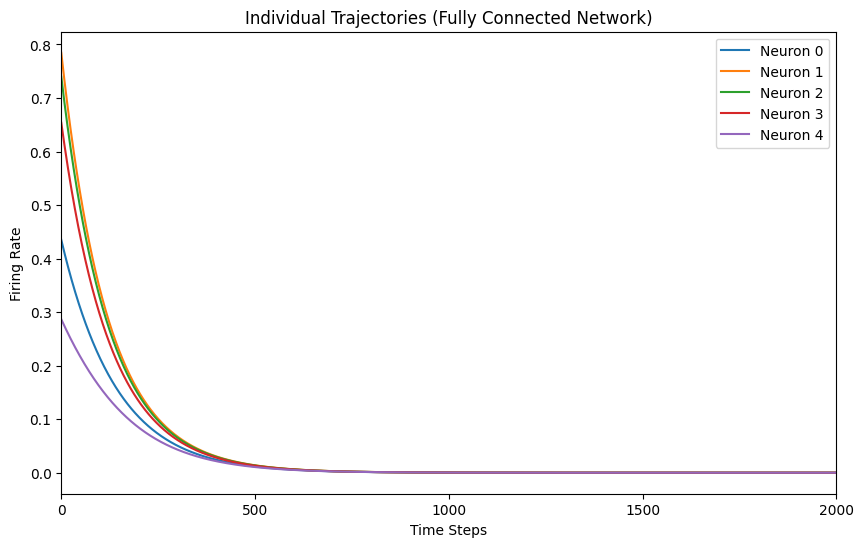

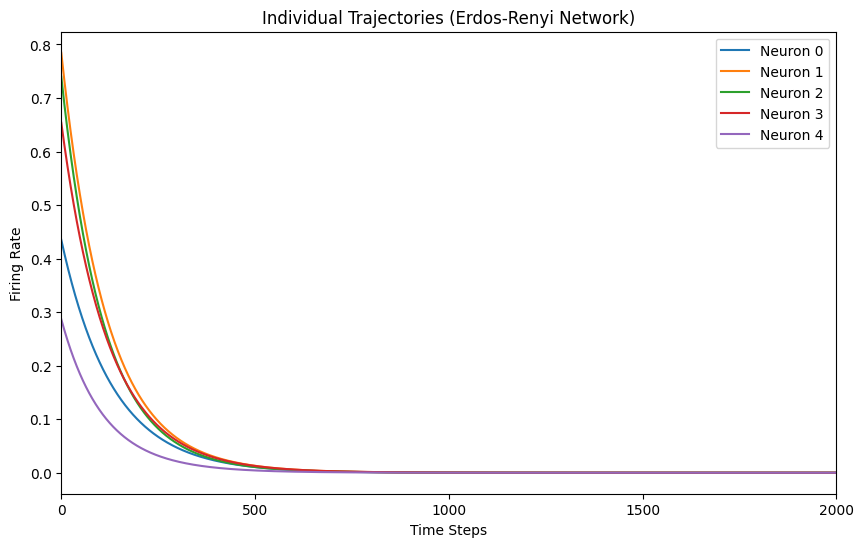

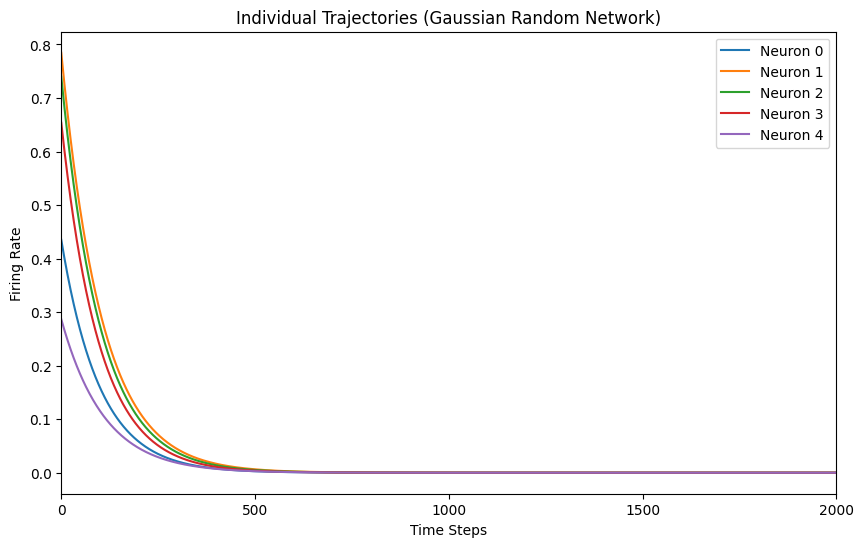

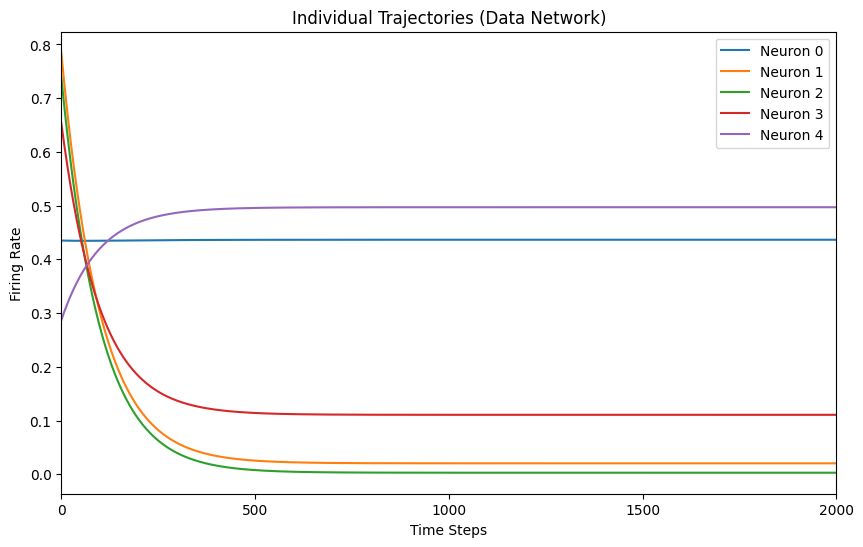

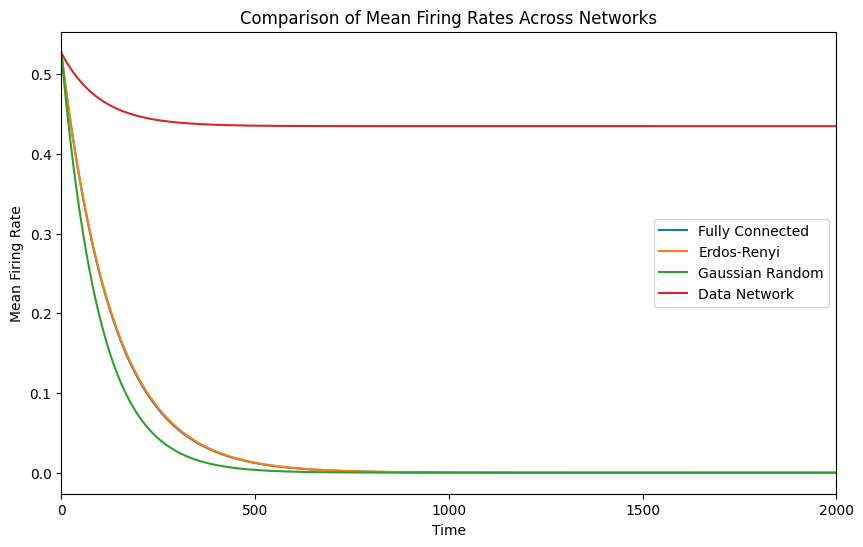

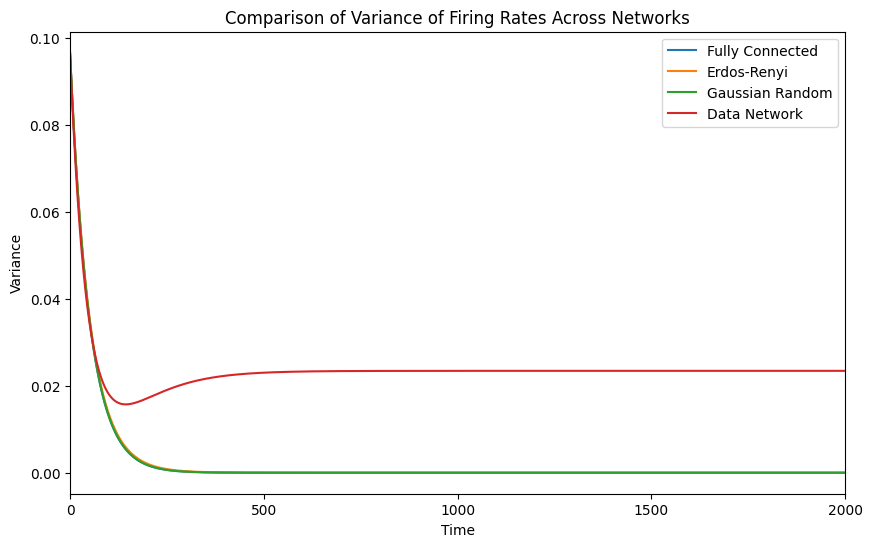

In [ ]:
# plot individual trajectories for each network type (firing rate evolution for each neuron over time)
networks = {
    "Fully Connected Network": rates_fully_connected,
    "Erdos-Renyi Network": rates_erdos_renyi,
    "Gaussian Random Network": rates_gaussian_random,
    "Data Network": rates_data_network,
}

for name, rates in networks.items():
    plt.figure(figsize=(10, 6))
    for i in range(min(5, rates.shape[1])):  # labels for first 5 neurons
        plt.plot(rates[:, i], label=f'Neuron {i}')
    plt.title(f'Individual Trajectories ({name})')
    plt.xlabel('Time Steps')
    plt.ylabel('Firing Rate')
    plt.legend()
    plt.xlim(0, 2000)  # limit to 2000 time steps
    plt.xticks(np.arange(0, 2001, 500))
    plt.show()

# compare how different network topologies affect the system's behaviour

# compare mean firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(mean_firing_rate_fully_connected, label='Fully Connected')
plt.plot(mean_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(mean_firing_rate_gaussian_random, label='Gaussian Random')
plt.plot(mean_firing_rate_data_network, label='Data Network')
plt.title('Comparison of Mean Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Mean Firing Rate')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()

# compare variance of firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(variance_firing_rate_fully_connected, label='Fully Connected')
plt.plot(variance_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(variance_firing_rate_gaussian_random, label='Gaussian Random')
plt.plot(variance_firing_rate_data_network, label='Data Network')
plt.title('Comparison of Variance of Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Variance')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()